In [1]:
import os
import re
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

folder = Path("../results_files_ML/100160TeV_025deg_4FF_180R175h_Black_13peSM_13peBKG_13peTEST_d0600_500ns")

roc_files = sorted(folder.glob("*_roc_points.txt"))
legend_files = sorted(folder.glob("*_legend_info.txt"))


def get_tag(path):
    name = path.name
    name = name.replace("_roc_points.txt", "")
    name = name.replace("_legend_info.txt", "")
    return name


def get_detector(tag):
    tag_low = tag.lower()

    if tag_low.startswith("8inch") or tag_low.startswith("8inches"):
        return "8inch"

    return "mpmt"


def clean_validation_tag(tag):
    tag_low = tag.lower()
    tag_low = tag_low.replace("8inch_", "")
    tag_low = tag_low.replace("8inches_", "")
    return tag_low


def get_validation_percent(tag):
    clean_tag = clean_validation_tag(tag)

    m = re.search(r"(\d+)%val", clean_tag, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    return None


def read_legend_info(path):
    info = {}

    with open(path, "r") as f:
        lines = f.readlines()

    current_block = None

    for line in lines:
        line = line.strip()

        if line == "Validation curve":
            current_block = "val_curve"
            continue

        if line == "Test curve":
            current_block = "test_curve"
            continue

        if line == "Validation cut applied to validation":
            current_block = "val_cut_on_val"
            continue

        if line == "Validation cut applied to test":
            current_block = "val_cut_on_test"
            continue

        if "=" not in line:
            continue

        key, value = [x.strip() for x in line.split("=", 1)]

        full_key = key
        if current_block is not None:
            full_key = f"{current_block}_{key}"

        try:
            info[full_key] = float(value)
        except ValueError:
            info[full_key] = value

    return info


legend_by_tag = {
    get_tag(path): path
    for path in legend_files
}

data = {
    "mpmt": {},
    "8inch": {}
}

for roc_file in roc_files:
    tag = get_tag(roc_file)
    detector = get_detector(tag)
    val_percent = get_validation_percent(tag)

    if val_percent is None:
        print(f"Skipping file, validation percentage not found: {roc_file.name}")
        continue

    legend_file = legend_by_tag.get(tag)

    if legend_file is None:
        print(f"Skipping file, matching legend not found for: {roc_file.name}")
        continue

    arr = np.loadtxt(roc_file)

    data[detector][val_percent] = {
        "tag": tag,
        "roc_file": roc_file,
        "legend_file": legend_file,
        "tpr_val": arr[:, 1],
        "fpr_val": arr[:, 2],
        "thr_val": arr[:, 3],
        "tpr_test": arr[:, 4],
        "fpr_test": arr[:, 5],
        "thr_test": arr[:, 6],
        "info": read_legend_info(legend_file),
    }

print("mPMT validation percentages found:", sorted(data["mpmt"].keys()))
print("8inch validation percentages found:", sorted(data["8inch"].keys()))


mPMT validation percentages found: [20, 30, 40, 50, 60, 80]
8inch validation percentages found: [20, 30, 40, 50, 60, 80]


In [2]:
def plot_validation_split_comparison(data_detector, detector_label, suptitle, save_path=None):

    valid_keys = sorted(data_detector.keys())

    nplots = len(valid_keys)
    ncols = 3
    nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 6 * nrows),
        squeeze=False
    )

    axes = axes.flatten()

    for ax, val_percent in zip(axes, valid_keys):

        d = data_detector[val_percent]
        info = d["info"]

        geff_val = info.get("val_cut_on_val_Gamma efficiency", np.nan)
        fpr_val_cut = info.get("val_cut_on_val_Proton fraction / FPR", np.nan)

        geff_test = info.get("val_cut_on_test_Gamma efficiency", np.nan)
        fpr_test_cut = info.get("val_cut_on_test_Proton fraction / FPR", np.nan)

        p_val = info.get("val_curve_Proton entries", np.nan)
        g_val = info.get("val_curve_Gamma entries", np.nan)

        p_test = info.get("test_curve_Proton entries", np.nan)
        g_test = info.get("test_curve_Gamma entries", np.nan)

        ax.plot(
            d["tpr_val"],
            d["fpr_val"],
            lw=1.8,
            ls="-",
            color="black",
            label=(
                "validation\n"
                rf"$\gamma_{{\mathrm{{eff}}}}={geff_val:.3f}$" "\n"
                rf"$p_{{\mathrm{{eff}}}}={fpr_val_cut:.2e}$"
            )
        )

        ax.plot(
            d["tpr_test"],
            d["fpr_test"],
            lw=1.8,
            ls="-",
            color="red",
            label=(
                "test\n"
                rf"$\gamma_{{\mathrm{{eff}}}}={geff_test:.3f}$" "\n"
                rf"$p_{{\mathrm{{eff}}}}={fpr_test_cut:.2e}$"
            )
        )

        if not np.isnan(geff_val) and not np.isnan(fpr_val_cut):
            ax.scatter(
                geff_val,
                fpr_val_cut,
                color="black",
                marker="v",
                s=100,
                zorder=5
            )

        if not np.isnan(geff_test) and not np.isnan(fpr_test_cut):
            ax.scatter(
                geff_test,
                fpr_test_cut,
                color="red",
                marker="v",
                s=100,
                zorder=5
            )

        for spine in ax.spines.values():
            spine.set_linewidth(2)

        ax.tick_params(axis="both", which="major", labelsize=16, length=6)
        ax.minorticks_off()

        ax.set_xlabel(r"$\gamma_{\mathrm{eff}}$", fontsize=18)
        ax.set_ylabel(r"$p_{\mathrm{eff}}$", fontsize=18)

        ax.set_yscale("log")
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(0.51e-3, 1.6)

        ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1])
        ax.grid(True, alpha=0.2)

        ax.set_title(
            rf"{val_percent}% validation, {100 - val_percent}% test"
            "\n"
            rf"validation: p={int(p_val) if not np.isnan(p_val) else '?'}, "
            rf"$\gamma$={int(g_val) if not np.isnan(g_val) else '?'}"
            "\n"
            rf"test: p={int(p_test) if not np.isnan(p_test) else '?'}, "
            rf"$\gamma$={int(g_test) if not np.isnan(g_test) else '?'}",
            fontsize=14
        )

        ax.legend(
            fontsize=12,
            edgecolor="black",
            facecolor="white",
            framealpha=1.0,
            loc="upper left",
            ncols=2
        )

    for ax in axes[nplots:]:
        ax.axis("off")

    plt.suptitle(f"{suptitle} - {detector_label}", fontsize=25, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

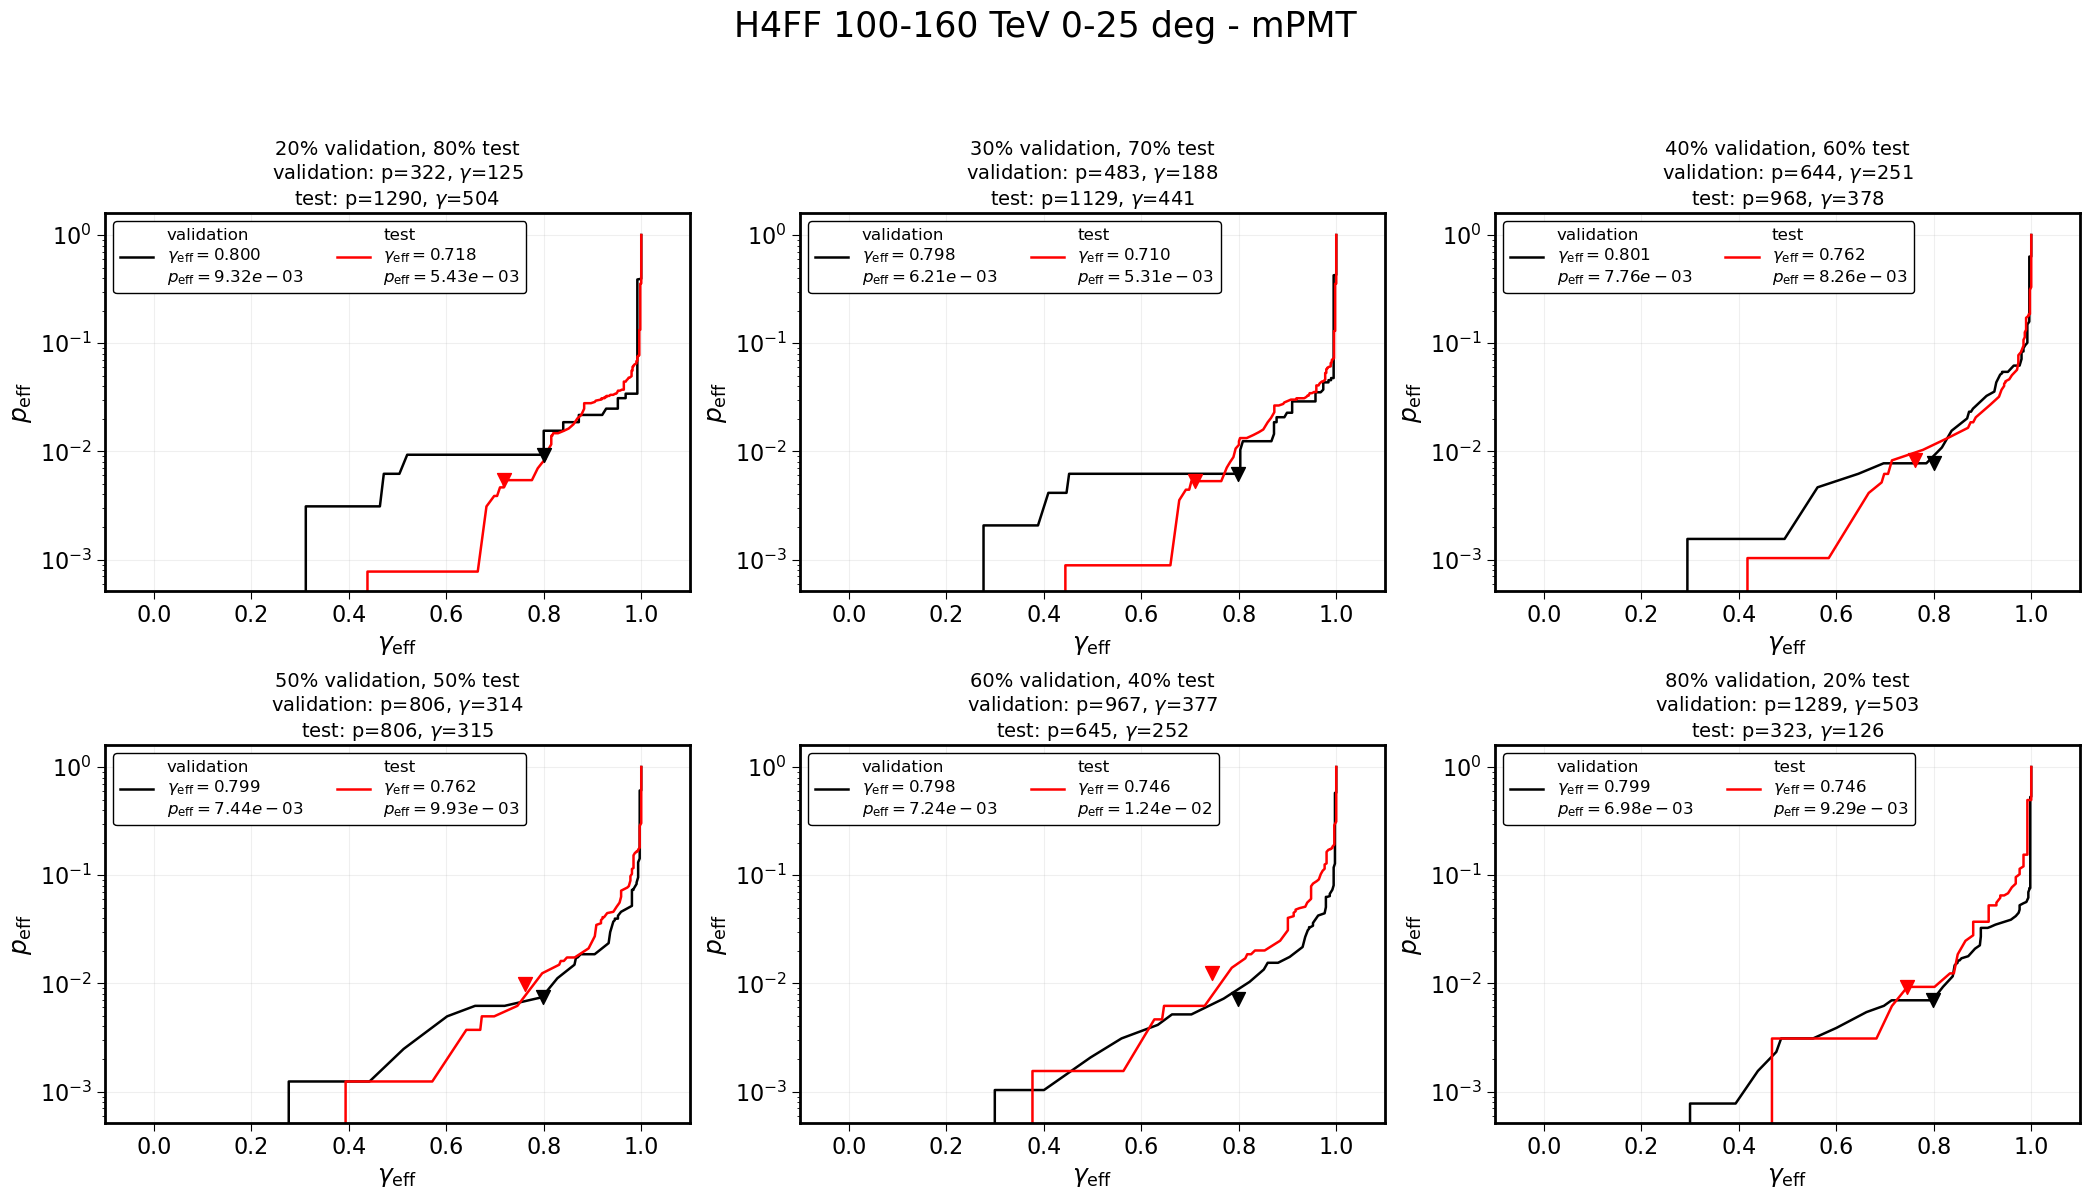

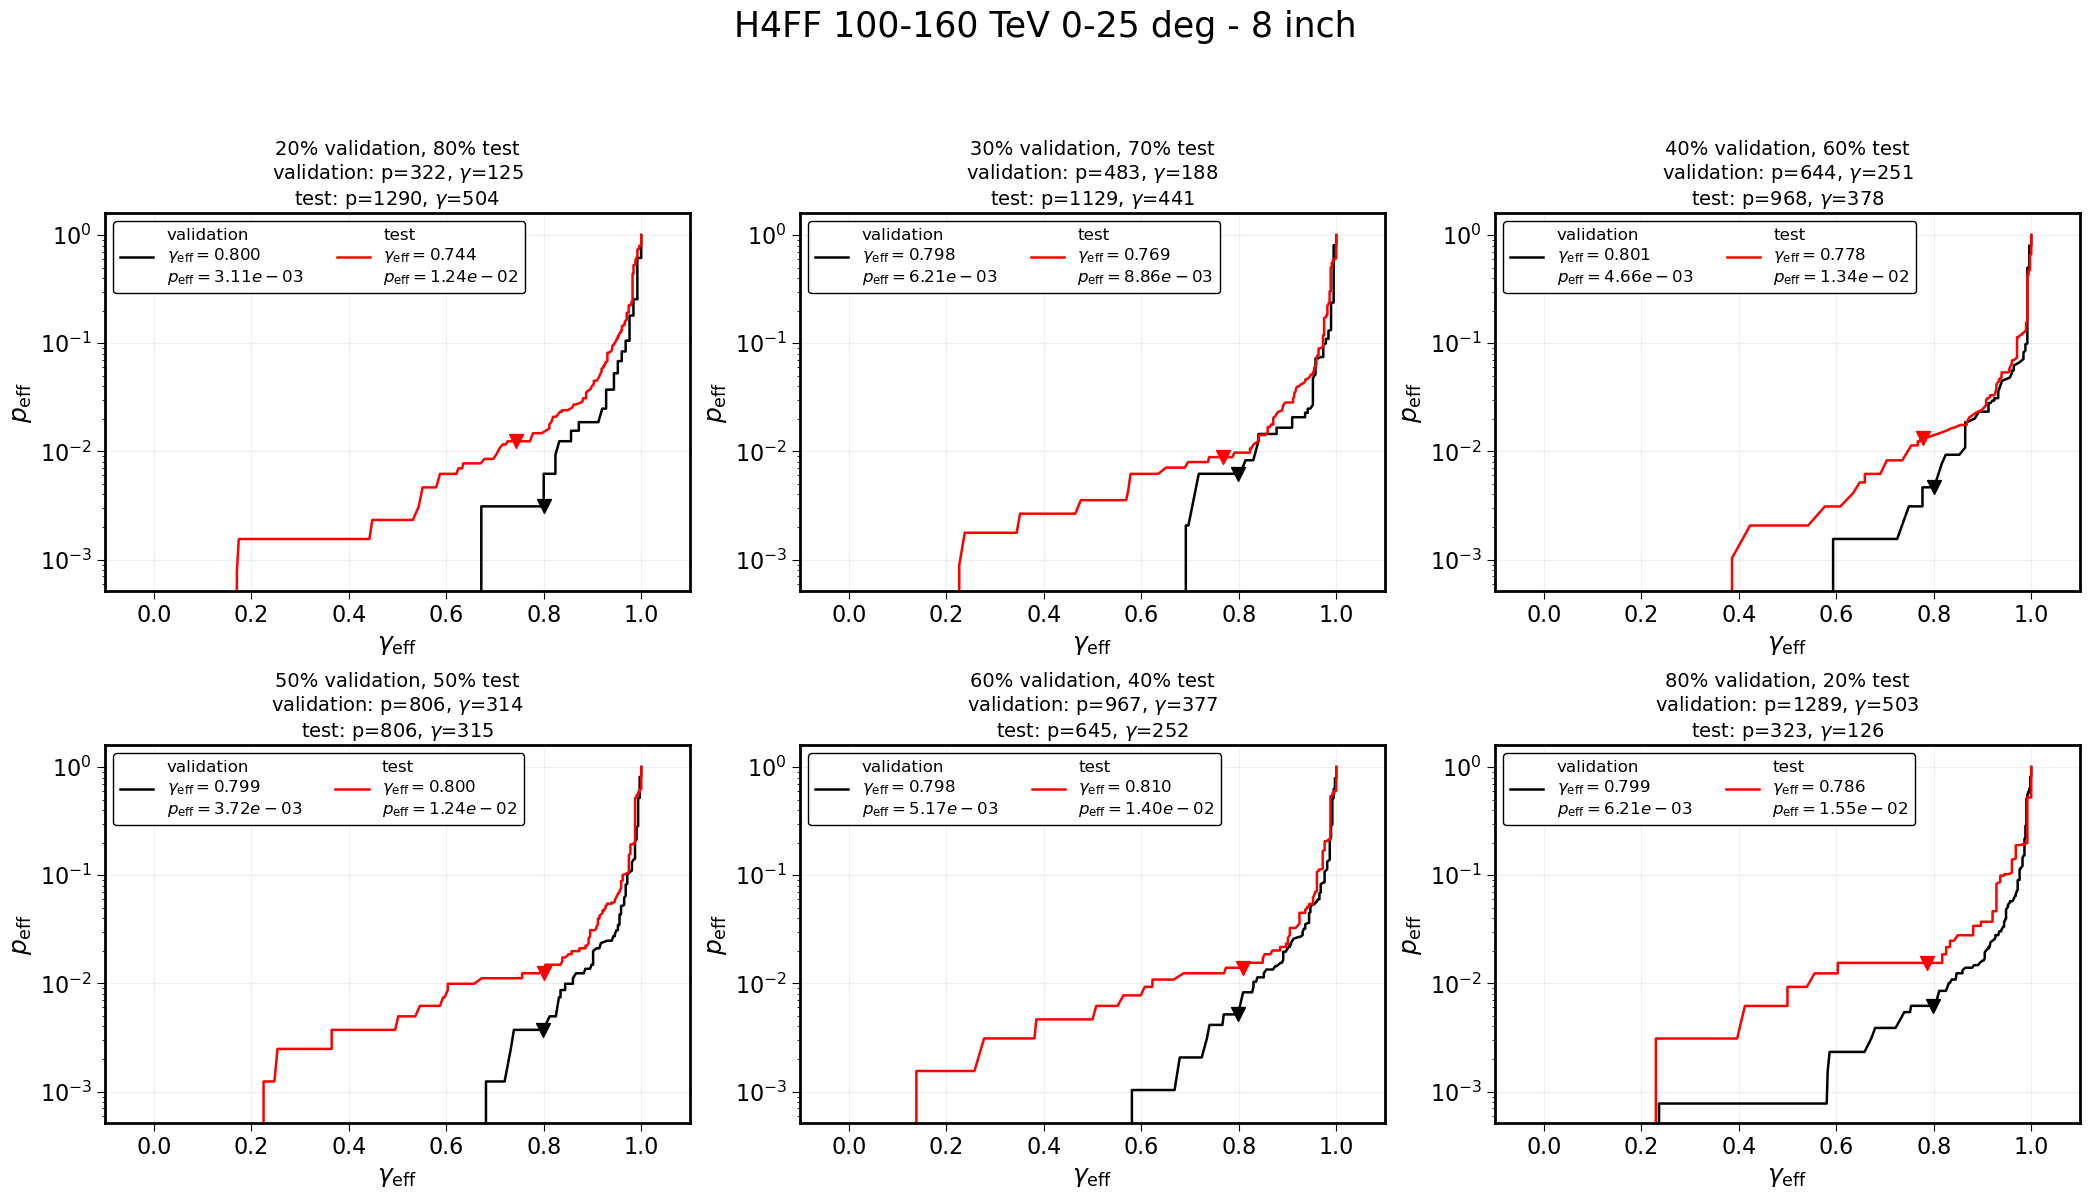

In [3]:
plot_validation_split_comparison(
    data["mpmt"],
    detector_label="mPMT",
    suptitle="H4FF 100-160 TeV 0-25 deg",
    save_path="../pictures/mPMT/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/validation_split_comparison_mPMT.png"
)

plot_validation_split_comparison(
    data["8inch"],
    detector_label="8 inch",
    suptitle="H4FF 100-160 TeV 0-25 deg",
    save_path="../pictures/mPMT/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/validation_split_comparison_8inch.png"
)

Common validation percentages: [20, 30, 40, 50, 60, 80]


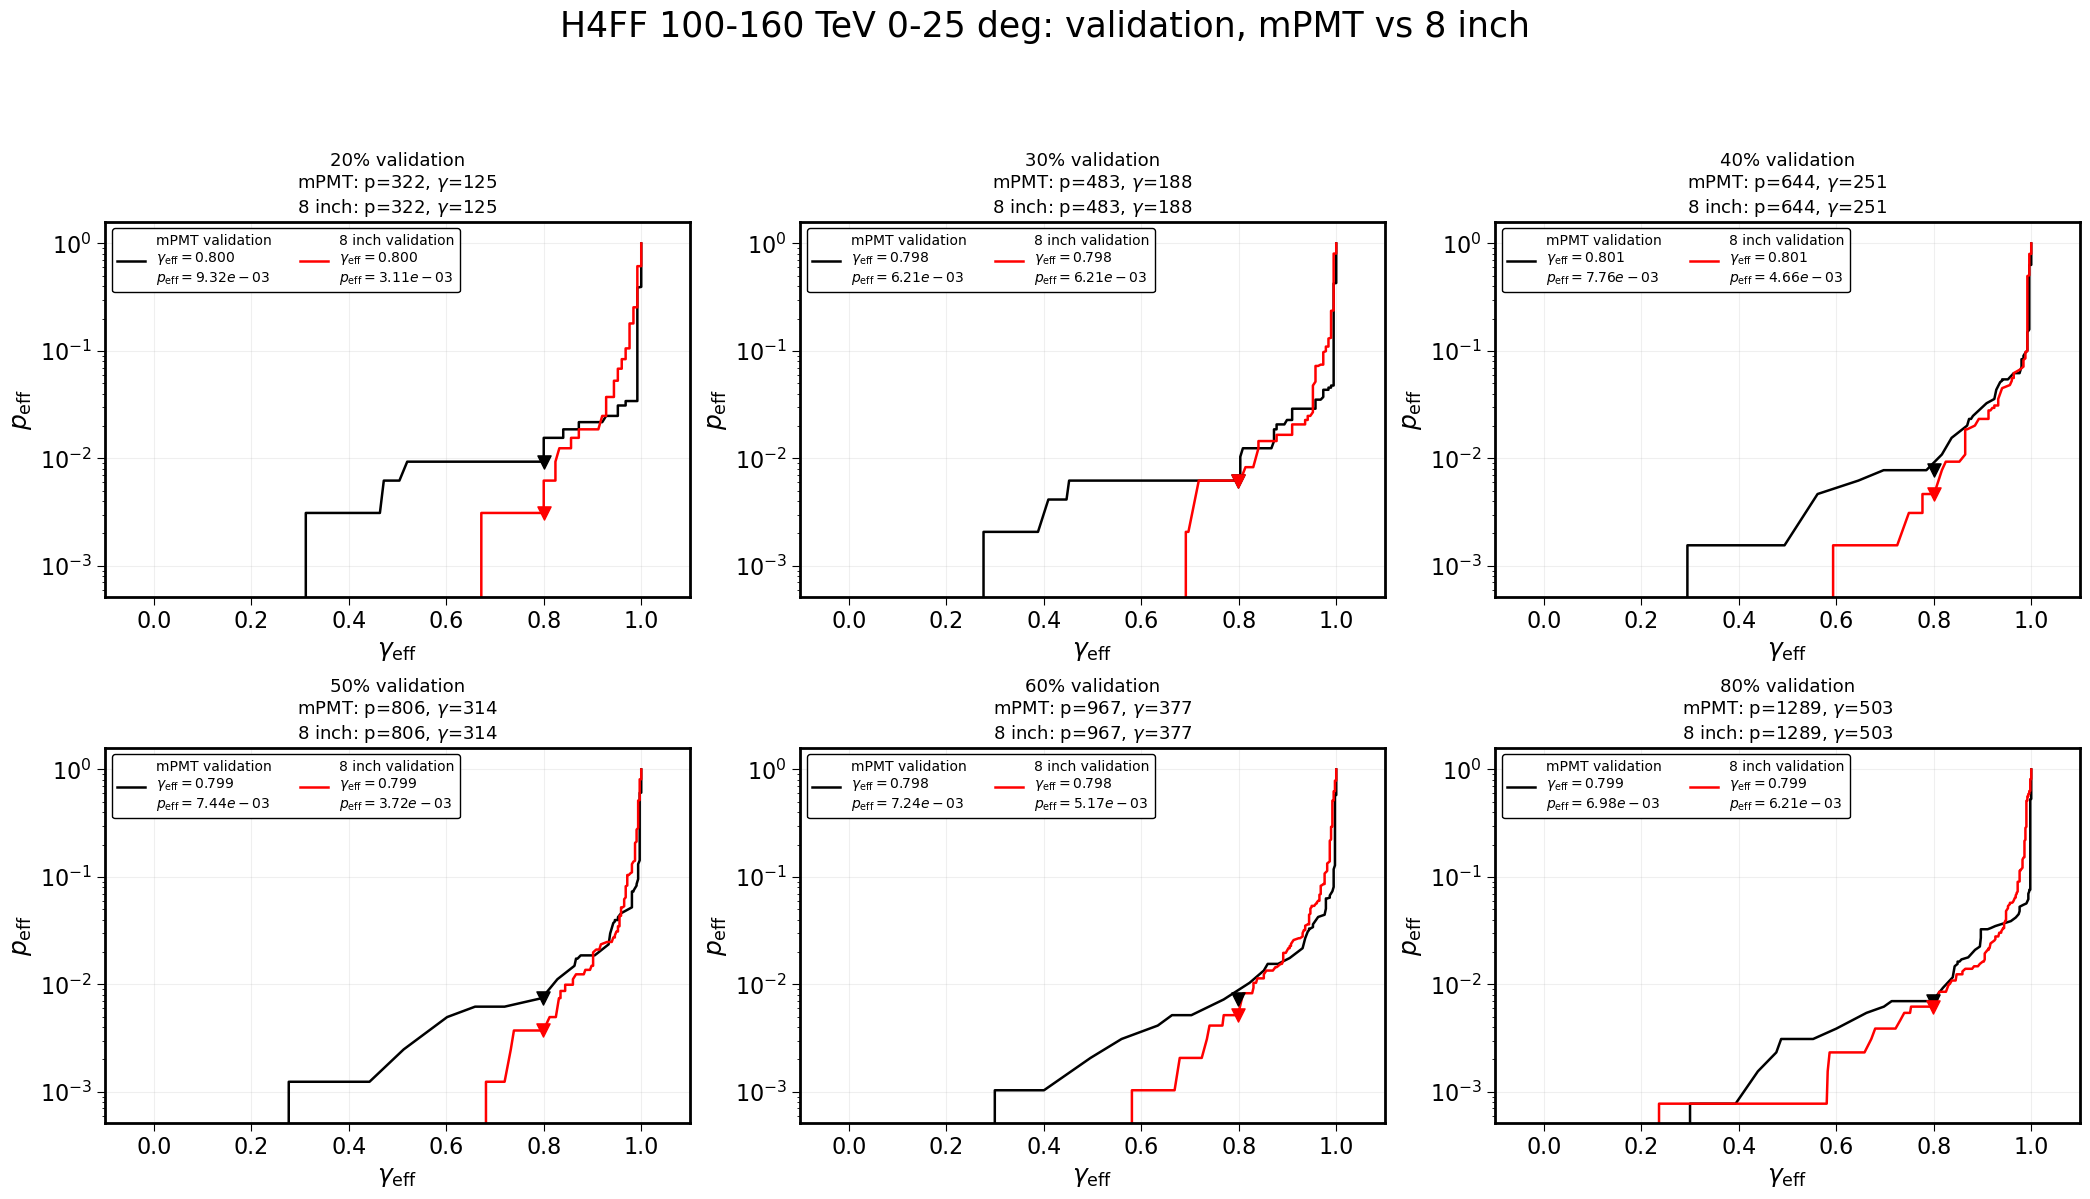

In [4]:
common_keys = sorted(
    set(data["mpmt"].keys()) & set(data["8inch"].keys())
)

print("Common validation percentages:", common_keys)

nplots = len(common_keys)
ncols = 3
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(7 * ncols, 6 * nrows),
    squeeze=False
)

axes = axes.flatten()

for ax, val_percent in zip(axes, common_keys):

    dm = data["mpmt"][val_percent]
    d8 = data["8inch"][val_percent]

    infom = dm["info"]
    info8 = d8["info"]

    geff_m_val = infom.get("val_cut_on_val_Gamma efficiency", np.nan)
    fpr_m_val = infom.get("val_cut_on_val_Proton fraction / FPR", np.nan)

    geff_8_val = info8.get("val_cut_on_val_Gamma efficiency", np.nan)
    fpr_8_val = info8.get("val_cut_on_val_Proton fraction / FPR", np.nan)

    p_m_val = infom.get("val_curve_Proton entries", np.nan)
    g_m_val = infom.get("val_curve_Gamma entries", np.nan)

    p_8_val = info8.get("val_curve_Proton entries", np.nan)
    g_8_val = info8.get("val_curve_Gamma entries", np.nan)

    ax.plot(
        dm["tpr_val"],
        dm["fpr_val"],
        lw=1.8,
        ls="-",
        color="black",
        label=(
            "mPMT validation\n"
            rf"$\gamma_{{\mathrm{{eff}}}}={geff_m_val:.3f}$" "\n"
            rf"$p_{{\mathrm{{eff}}}}={fpr_m_val:.2e}$"
        )
    )

    ax.plot(
        d8["tpr_val"],
        d8["fpr_val"],
        lw=1.8,
        ls="-",
        color="red",
        label=(
            "8 inch validation\n"
            rf"$\gamma_{{\mathrm{{eff}}}}={geff_8_val:.3f}$" "\n"
            rf"$p_{{\mathrm{{eff}}}}={fpr_8_val:.2e}$"
        )
    )

    if not np.isnan(geff_m_val) and not np.isnan(fpr_m_val):
        ax.scatter(
            geff_m_val,
            fpr_m_val,
            color="black",
            marker="v",
            s=90,
            zorder=5
        )

    if not np.isnan(geff_8_val) and not np.isnan(fpr_8_val):
        ax.scatter(
            geff_8_val,
            fpr_8_val,
            color="red",
            marker="v",
            s=90,
            zorder=5
        )

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.tick_params(axis="both", which="major", labelsize=16, length=6)
    ax.minorticks_off()

    ax.set_xlabel(r"$\gamma_{\mathrm{eff}}$", fontsize=18)
    ax.set_ylabel(r"$p_{\mathrm{eff}}$", fontsize=18)

    ax.set_yscale("log")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(0.51e-3, 1.6)

    ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1])
    ax.grid(True, alpha=0.2)

    ax.set_title(
        rf"{val_percent}% validation"
        "\n"
        rf"mPMT: p={int(p_m_val) if not np.isnan(p_m_val) else '?'}, "
        rf"$\gamma$={int(g_m_val) if not np.isnan(g_m_val) else '?'}"
        "\n"
        rf"8 inch: p={int(p_8_val) if not np.isnan(p_8_val) else '?'}, "
        rf"$\gamma$={int(g_8_val) if not np.isnan(g_8_val) else '?'}",
        fontsize=13
    )

    ax.legend(
        fontsize=10,
        edgecolor="black",
        facecolor="white",
        framealpha=1.0,
        loc="upper left",
        ncols=2
    )

for ax in axes[nplots:]:
    ax.axis("off")

plt.suptitle("H4FF 100-160 TeV 0-25 deg: validation, mPMT vs 8 inch", fontsize=25, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    "../pictures/mPMT/100160TeV_025deg_4FF_180R175h_Black/"
    "XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/"
    "validation_split_comparison_validation_mPMT_vs_8inch.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

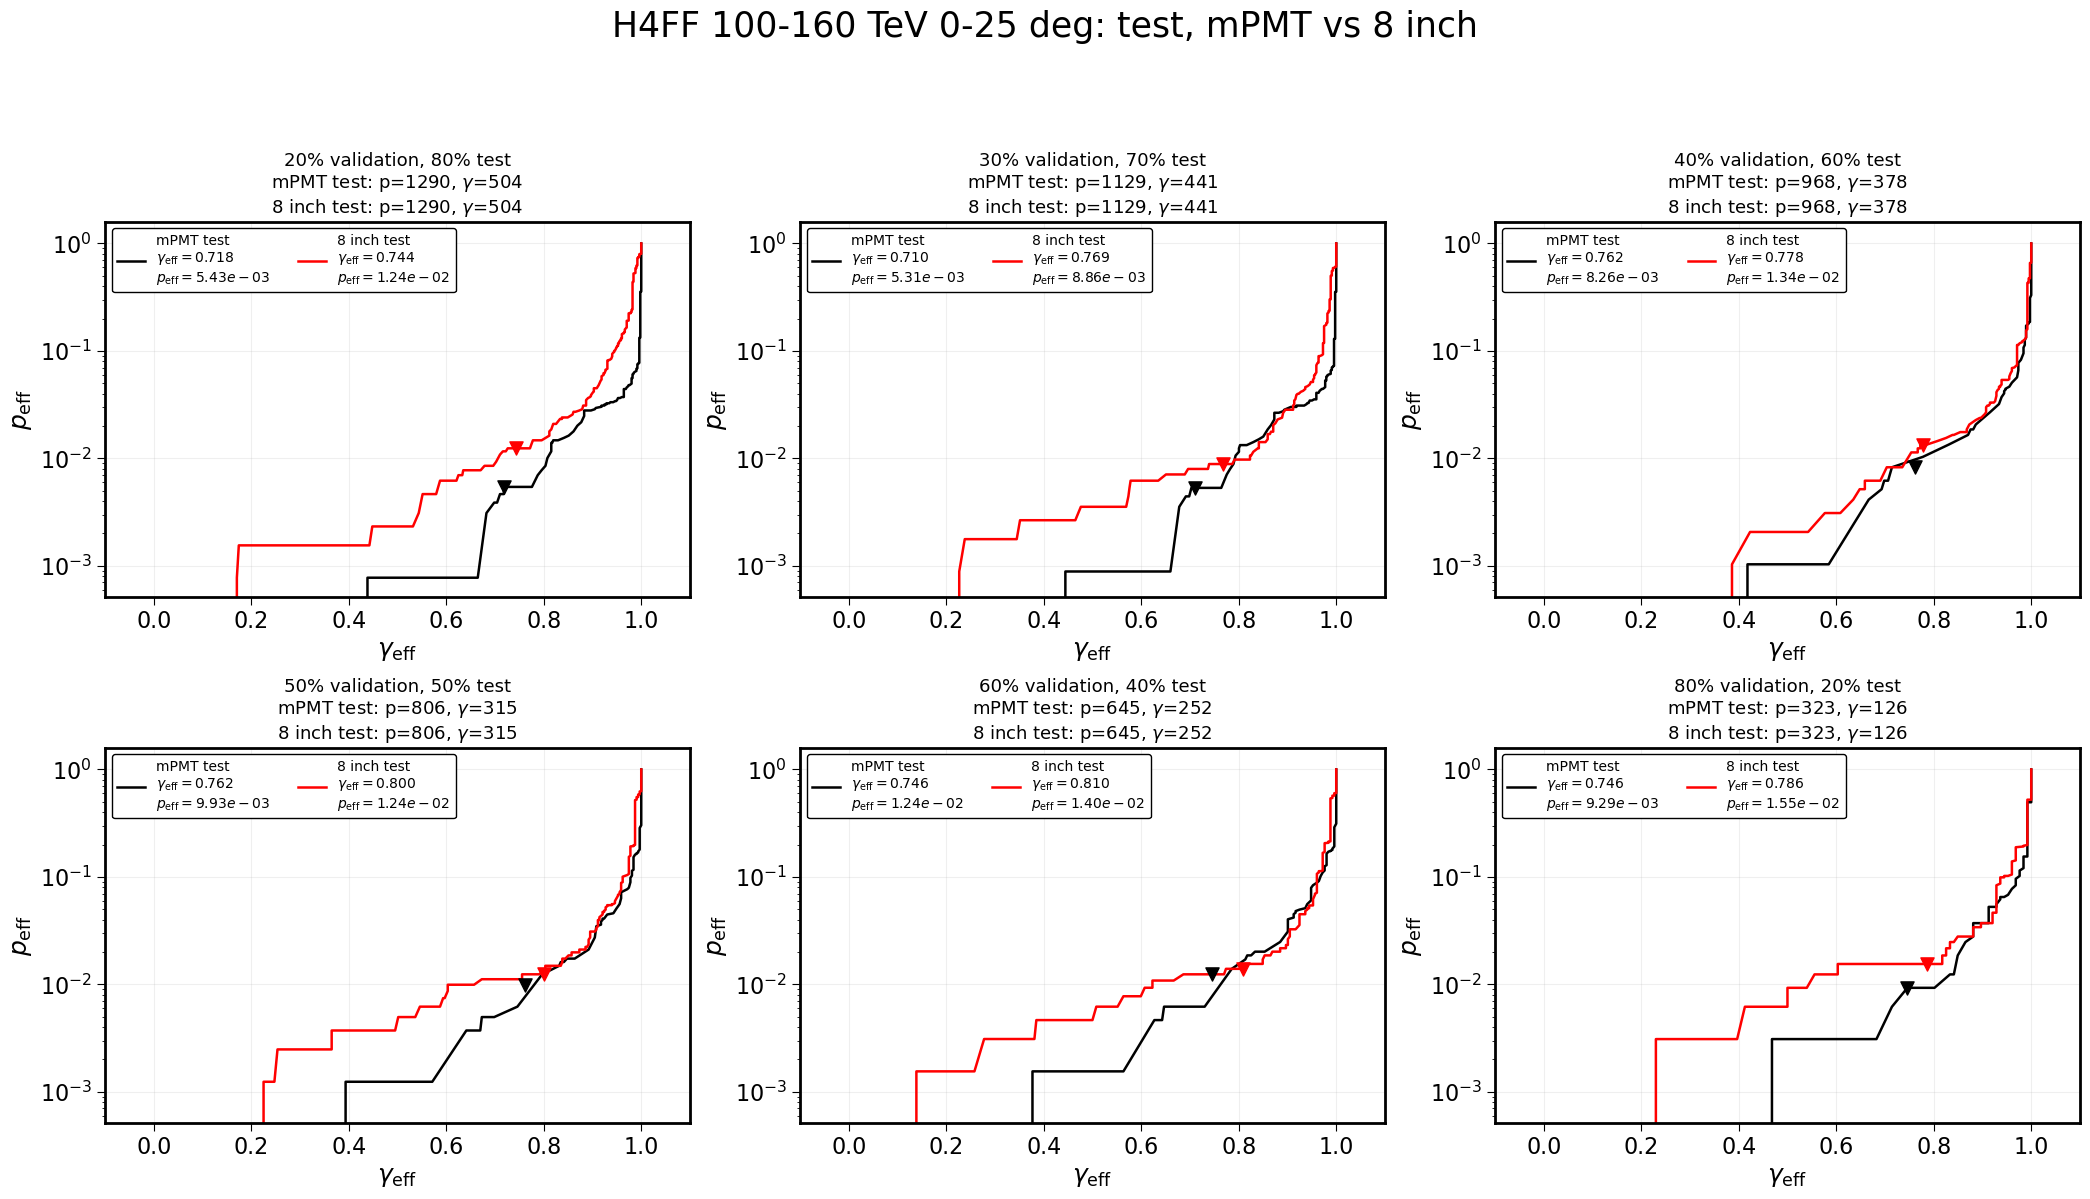

In [5]:
nplots = len(common_keys)
ncols = 3
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(7 * ncols, 6 * nrows),
    squeeze=False
)

axes = axes.flatten()

for ax, val_percent in zip(axes, common_keys):

    dm = data["mpmt"][val_percent]
    d8 = data["8inch"][val_percent]

    infom = dm["info"]
    info8 = d8["info"]

    geff_m_test = infom.get("val_cut_on_test_Gamma efficiency", np.nan)
    fpr_m_test = infom.get("val_cut_on_test_Proton fraction / FPR", np.nan)

    geff_8_test = info8.get("val_cut_on_test_Gamma efficiency", np.nan)
    fpr_8_test = info8.get("val_cut_on_test_Proton fraction / FPR", np.nan)

    p_m_test = infom.get("test_curve_Proton entries", np.nan)
    g_m_test = infom.get("test_curve_Gamma entries", np.nan)

    p_8_test = info8.get("test_curve_Proton entries", np.nan)
    g_8_test = info8.get("test_curve_Gamma entries", np.nan)

    ax.plot(
        dm["tpr_test"],
        dm["fpr_test"],
        lw=1.8,
        ls="-",
        color="black",
        label=(
            "mPMT test\n"
            rf"$\gamma_{{\mathrm{{eff}}}}={geff_m_test:.3f}$" "\n"
            rf"$p_{{\mathrm{{eff}}}}={fpr_m_test:.2e}$"
        )
    )

    ax.plot(
        d8["tpr_test"],
        d8["fpr_test"],
        lw=1.8,
        ls="-",
        color="red",
        label=(
            "8 inch test\n"
            rf"$\gamma_{{\mathrm{{eff}}}}={geff_8_test:.3f}$" "\n"
            rf"$p_{{\mathrm{{eff}}}}={fpr_8_test:.2e}$"
        )
    )

    if not np.isnan(geff_m_test) and not np.isnan(fpr_m_test):
        ax.scatter(
            geff_m_test,
            fpr_m_test,
            color="black",
            marker="v",
            s=90,
            zorder=5
        )

    if not np.isnan(geff_8_test) and not np.isnan(fpr_8_test):
        ax.scatter(
            geff_8_test,
            fpr_8_test,
            color="red",
            marker="v",
            s=90,
            zorder=5
        )

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.tick_params(axis="both", which="major", labelsize=16, length=6)
    ax.minorticks_off()

    ax.set_xlabel(r"$\gamma_{\mathrm{eff}}$", fontsize=18)
    ax.set_ylabel(r"$p_{\mathrm{eff}}$", fontsize=18)

    ax.set_yscale("log")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(0.51e-3, 1.6)

    ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1])
    ax.grid(True, alpha=0.2)

    ax.set_title(
        rf"{val_percent}% validation, {100 - val_percent}% test"
        "\n"
        rf"mPMT test: p={int(p_m_test) if not np.isnan(p_m_test) else '?'}, "
        rf"$\gamma$={int(g_m_test) if not np.isnan(g_m_test) else '?'}"
        "\n"
        rf"8 inch test: p={int(p_8_test) if not np.isnan(p_8_test) else '?'}, "
        rf"$\gamma$={int(g_8_test) if not np.isnan(g_8_test) else '?'}",
        fontsize=13
    )

    ax.legend(
        fontsize=10,
        edgecolor="black",
        facecolor="white",
        framealpha=1.0,
        loc="upper left",
        ncols=2
    )

for ax in axes[nplots:]:
    ax.axis("off")

plt.suptitle("H4FF 100-160 TeV 0-25 deg: test, mPMT vs 8 inch", fontsize=25, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    "../pictures/mPMT/100160TeV_025deg_4FF_180R175h_Black/"
    "XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/"
    "validation_split_comparison_test_mPMT_vs_8inch.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()